# Kalman Filter as Dynamic Linear Regression

This notebook implements the Section 3.4 recursion directly on a BTC-ETH log-price pair.

The hidden state is a two-element vector:

- slope, interpreted as the dynamic hedge ratio in log-price space;
- intercept, interpreted as the current mean offset.

The forecast error divided by its model variance becomes a Bollinger-like signal.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


def find_repo_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "fixtures/crypto/crypto_daily_close.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Missing shared crypto fixture: fixtures/crypto/crypto_daily_close.csv. "
        "Run `python3 scripts/python/download-crypto-fixtures.py --source binance-monthly-archive` "
        "from the repository root."
    )


repo_root = find_repo_root()
close = pd.read_csv(
    repo_root / "fixtures/crypto/crypto_daily_close.csv",
    parse_dates=["date"],
).set_index("date").sort_index()
close = close.apply(pd.to_numeric, errors="coerce").dropna(how="all")

symbols = ["BTCUSDT", "ETHUSDT"]
missing = [symbol for symbol in symbols if symbol not in close]
if missing:
    raise ValueError(f"Fixture is missing required symbols: {missing}")

prices = close[symbols].dropna()
prices.tail()


,BTCUSDT,ETHUSDT
date,,
2024-12-27,"94,299.030000","3,333.510000"
2024-12-28,"95,300.000000","3,404.000000"
2024-12-29,"93,738.200000","3,356.480000"
2024-12-30,"92,792.050000","3,361.840000"
2024-12-31,"93,576.000000","3,337.780000"


In [2]:
def kalman_dynamic_regression(y: pd.Series, x: pd.Series, delta: float = 0.0001, ve: float = 0.001) -> pd.DataFrame:
    aligned = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    observation_model = np.column_stack([aligned["x"].to_numpy(), np.ones(len(aligned))])
    y_values = aligned["y"].to_numpy()

    vw = delta / (1 - delta) * np.eye(2)
    beta = np.zeros(2)
    p_cov = np.zeros((2, 2))

    rows = []
    for date, x_t, y_t in zip(aligned.index, observation_model, y_values):
        beta_prior = beta.copy()
        r_cov = p_cov + vw

        yhat = float(x_t @ beta_prior)
        q = float(x_t @ r_cov @ x_t.T + ve)
        error = float(y_t - yhat)
        gain = r_cov @ x_t.T / q

        beta = beta_prior + gain * error
        p_cov = r_cov - np.outer(gain, x_t) @ r_cov

        rows.append(
            {
                "date": date,
                "slope": beta[0],
                "intercept": beta[1],
                "yhat": yhat,
                "error": error,
                "Q": q,
                "zscore": error / np.sqrt(q),
                "gain_slope": gain[0],
                "gain_intercept": gain[1],
            }
        )
    return pd.DataFrame(rows).set_index("date")


log_prices = np.log(prices)
result = kalman_dynamic_regression(log_prices["ETHUSDT"], log_prices["BTCUSDT"])

# The zero-state initialization creates a large first-step error. Keep the full
# recursion in `result`, but use a short warm-up cut for diagnostics and plots.
warmup = 20
analysis_result = result.iloc[warmup:]
analysis_result.tail()


,slope,intercept,yhat,error,Q,zscore,gain_slope,gain_intercept
date,,,,,,,,
2024-12-27,0.703160,0.057027,8.102626,0.009155,0.015153,0.074372,0.080601,0.010789
2024-12-28,0.704303,0.057100,8.118602,0.014105,0.015181,0.114477,0.081031,0.005121
2024-12-29,0.704182,0.057084,8.120139,-0.001491,0.015139,-0.012121,0.080674,0.010368
2024-12-30,0.704881,0.057165,8.111603,0.008641,0.015117,0.070280,0.080820,0.009415
2024-12-31,0.703863,0.057097,8.125602,-0.012541,0.015139,-0.101927,0.081114,0.005471


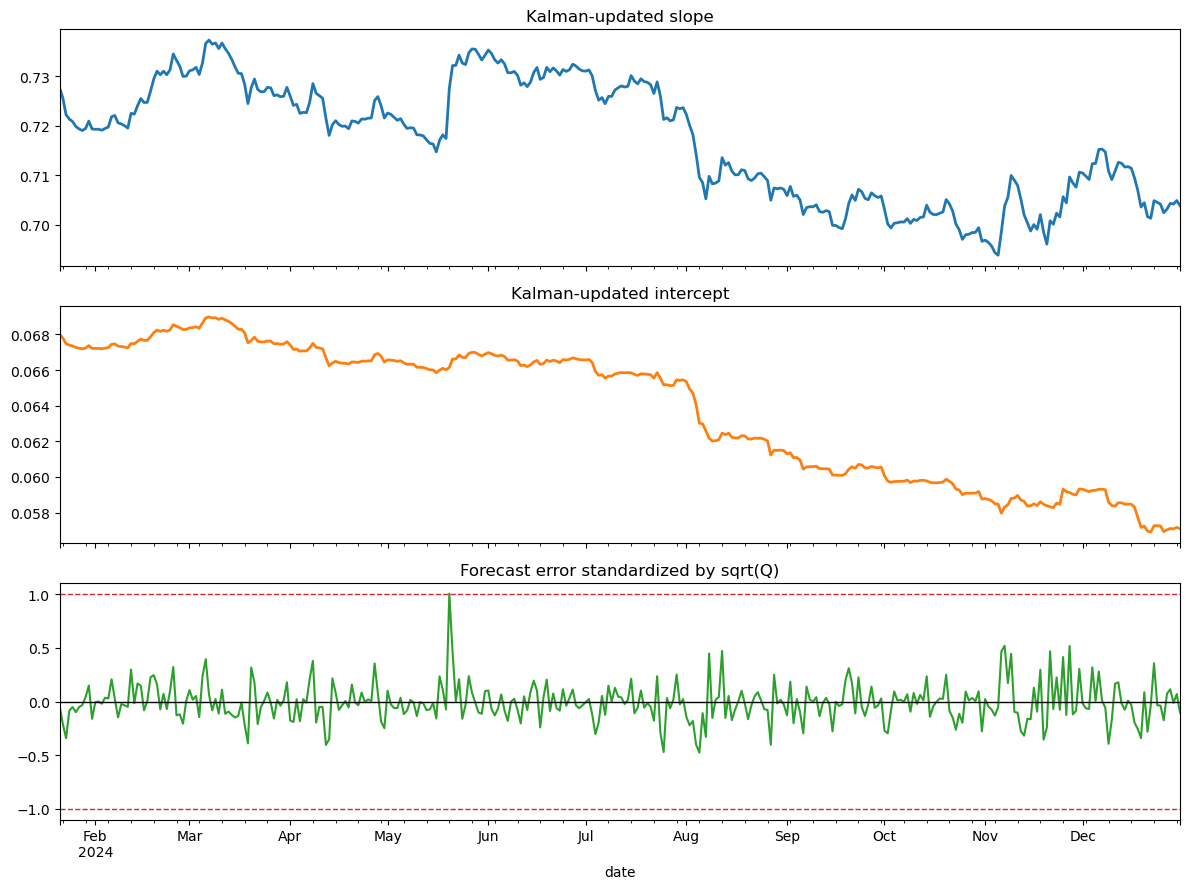

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

analysis_result["slope"].plot(ax=axes[0], linewidth=2, color="tab:blue")
axes[0].set_title("Kalman-updated slope")

analysis_result["intercept"].plot(ax=axes[1], linewidth=2, color="tab:orange")
axes[1].set_title("Kalman-updated intercept")

analysis_result["zscore"].plot(ax=axes[2], linewidth=1.5, color="tab:green")
axes[2].axhline(1, color="tab:red", linestyle="--", linewidth=1)
axes[2].axhline(-1, color="tab:red", linestyle="--", linewidth=1)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Forecast error standardized by sqrt(Q)")

plt.tight_layout();


In [4]:
entry = analysis_result["zscore"].abs() > 1
pd.Series(
    {
        "days_after_warmup": len(analysis_result),
        "entry_signal_days_abs_z_gt_1": int(entry.sum()),
        "median_forecast_error": analysis_result["error"].median(),
        "median_sqrt_Q": np.sqrt(analysis_result["Q"]).median(),
        "median_abs_slope_gain": analysis_result["gain_slope"].abs().median(),
    }
)

days_after_warmup              346.000000
entry_signal_days_abs_z_gt_1     1.000000
median_forecast_error           -0.002127
median_sqrt_Q                    0.119635
median_abs_slope_gain            0.083263
dtype: float64

In [5]:
comparison = []
for delta in [0.0, 0.0001, 0.001, 0.01]:
    out = kalman_dynamic_regression(log_prices["ETHUSDT"], log_prices["BTCUSDT"], delta=delta, ve=0.001).iloc[warmup:]
    comparison.append(
        {
            "delta": delta,
            "slope_std": out["slope"].std(),
            "mean_abs_zscore": out["zscore"].abs().mean(),
            "signal_days_abs_z_gt_1": int((out["zscore"].abs() > 1).sum()),
        }
    )
pd.DataFrame(comparison).set_index("delta")

,slope_std,mean_abs_zscore,signal_days_abs_z_gt_1
delta,,,
0.000000,0.000000,253.599220,346
0.000100,0.011871,0.126782,1
0.001000,0.011855,0.042818,0
0.010000,0.011853,0.013582,0


## Interpretation

The filter replaces rolling-window cutoffs with recursive state updates. The slope, intercept, and forecast-error variance are estimated together, so the trading signal is not just a spread level; it is a spread surprise relative to current model uncertainty.
